**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Fonction de coût](static/03-A-banner.png)
<br/>
**Objectif:** cette séance de travaux pratique a pour objectif la compréhension des différents aspects de la **fonction de coût** en régression linéaire simple

In [15]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

### 0 - Chargement des bibliothèques

In [16]:
# Manipulation de données
import numpy as np
import pandas as pd
from collections import defaultdict

# Visualisation de données
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import seaborn as sns

# Outils divers
from tqdm.notebook import tqdm_notebook
from tqdm import tqdm

In [17]:
# Configuration de la visualisation
sns.set_theme(style="darkgrid", rc={'figure.figsize':(11.7,8.27)})

### 1 - Simulation d'un jeu de données

In [18]:
m = 200

In [19]:
np.random.seed(2020) # Pour la reproductibilité des résultats
theta_0_th = -0.5
theta_1_th = 0.75
x = np.random.uniform(1,10,m)
y = theta_0_th + (theta_1_th * x) + np.random.randn(m) ## on ajoute une petite erreur. Équivalent de standard_normal 

Text(0, 0.5, 'y')

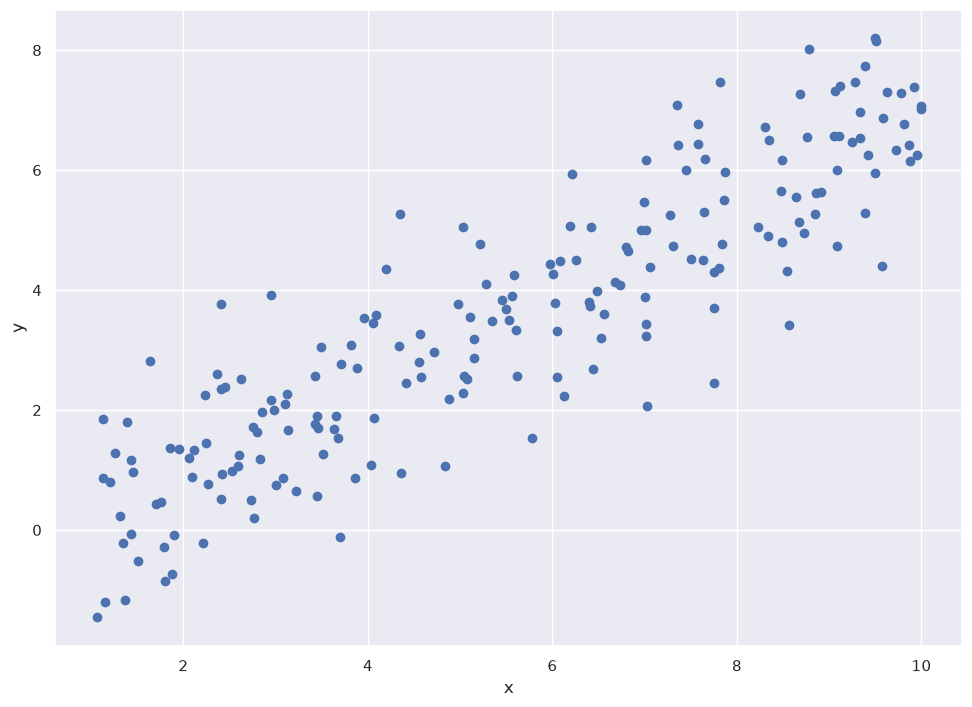

In [20]:
fig, ax = plt.subplots()
ax.scatter(x,y)
ax.set_xlabel("x")
ax.set_ylabel("y")

### 2 - Définition d'un modèle de régression linéaire simple

**Exercice 1**: compléter la fonction ci-dessous représentant le modèle de régression linéaire simple (hypothèse)

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Pour rappel, le modèle de régression linéaire simple est
$h_{\theta}(x)=\theta_{0} + \theta_{1}x$
</p>

In [21]:
def hypothesis(x, theta_0, theta_1):
    # Compléter le code ci-dessous ~ 1 ligne
    h = theta_0 + x * theta_1
    return h

### 3 - Règlage des paramètres de manière manuelle

**Exercice 2**: Faites varier les paramètres $\theta_0$ et $\theta_1$ de manière à obtenir un bon "fit" sur les données simulées

Text(0, 0.5, 'y')

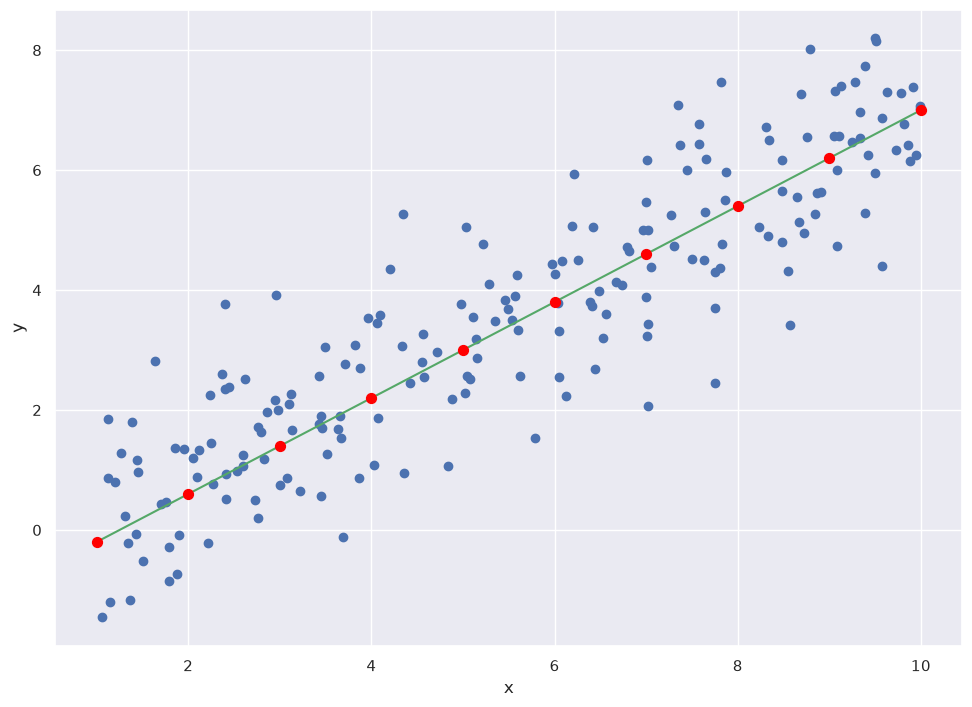

In [22]:
theta_0 = -1
theta_1 = 0.8

reg_x = np.linspace(1,10,10)
reg_y = hypothesis(np.linspace(1,10,10), theta_0, theta_1)
fig, ax = plt.subplots()
ax.scatter(x,y)
ax.plot(reg_x, reg_y, "g")


# Cercles rouges sur la droite
ax.scatter(
    reg_x,
    reg_y,
    color="red",
    marker="o",
    s=50,
    zorder=3
)

ax.set_xlabel("x")
ax.set_ylabel("y")

### 4 - Définition de la fonction de coût

**Exercice 3**: Compléter la fonction de coût ci-dessous

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Pour rappel, la fonction de coût en régression linéaire simple s'exprime sous la forme
$J(\theta_{0},\theta_{1})= \frac{1}{2m}\sum\limits_{i=1}^{m}(h_{\theta}(x^{(i)})-y^{(i)})^{2}$
</p>

In [23]:
def cost_function(x,y, theta_0, theta_1):
    assert len(x) == len(y)
    y_calc = hypothesis(x,theta_0, theta_1)
    # Compléter le code ci dessous ~ 1-4 lignes
    cost =  np.sum( ( y_calc-y)**2 )/(2*len(x))
    return cost

Pour l'illustration suivante, nous fixerons $\theta_0$ à 0 et ferons varier $\theta_1$ sur un interval donné

Le modèle (ou l'hypothèse) sera donc $h_{\theta}(x) = \theta_{1}x$

In [24]:
thetas = np.linspace(-1,2,20)
J = []
theta_0 = 0
for theta_1 in thetas:
    J.append(cost_function(x, y, theta_0, theta_1))

**Exercice 4**: selon la courbe ci-dessus, quelle est approximativement la valeur de $\theta_1$ qui minimise la fonction de coût ?

0


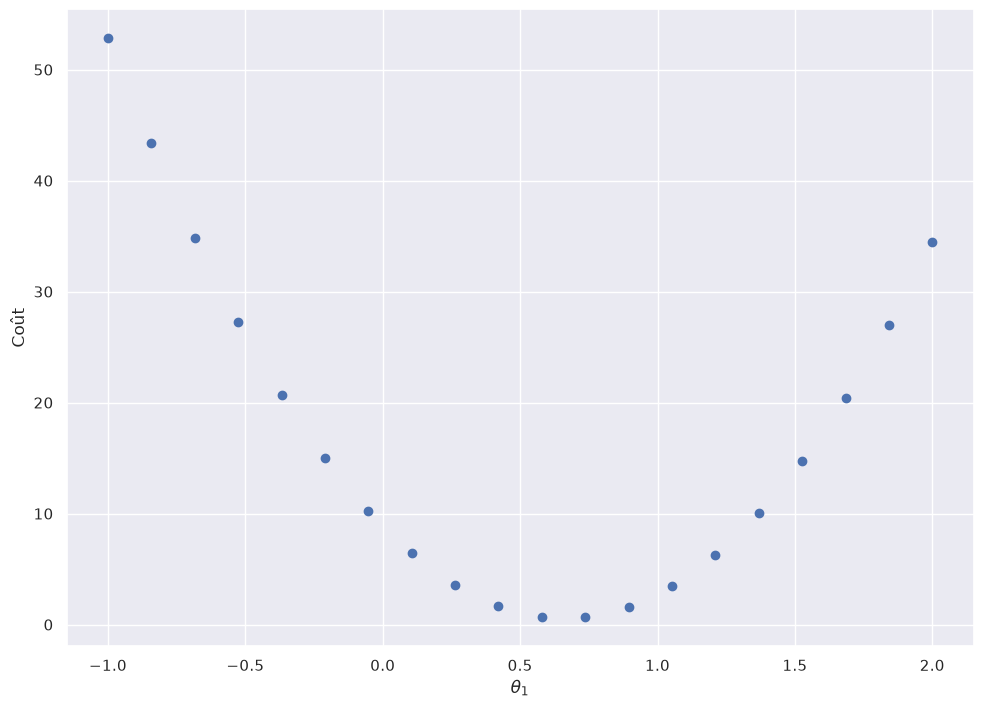

In [25]:
fig, ax = plt.subplots()
ax.scatter(thetas, J)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel("Coût")
print(theta_0)

### 5 - Modèle complet

$h_{\theta}(x) = \theta_{0} + \theta_{1}x$

In [26]:
theta_0s = np.linspace(-4,2,50)
theta_1s = np.linspace(-1,2,50)
mesh = np.zeros((50,50))
for i, theta0 in enumerate(theta_0s):
    for j, theta1 in enumerate(theta_1s):
        mesh[i,j] = cost_function(x, y, theta0, theta1)



**Exercice 5**: selon la courbe ci-dessus, quelle sont approximativement les valeurs de $\theta_{0}$ et $\theta_{1}$ qui minimisent la fonction de coût ?

[[-1.         -0.93877551 -0.87755102 ...  1.87755102  1.93877551
   2.        ]
 [-1.         -0.93877551 -0.87755102 ...  1.87755102  1.93877551
   2.        ]
 [-1.         -0.93877551 -0.87755102 ...  1.87755102  1.93877551
   2.        ]
 ...
 [-1.         -0.93877551 -0.87755102 ...  1.87755102  1.93877551
   2.        ]
 [-1.         -0.93877551 -0.87755102 ...  1.87755102  1.93877551
   2.        ]
 [-1.         -0.93877551 -0.87755102 ...  1.87755102  1.93877551
   2.        ]]


Text(0, 0.5, '$\\theta_1$')

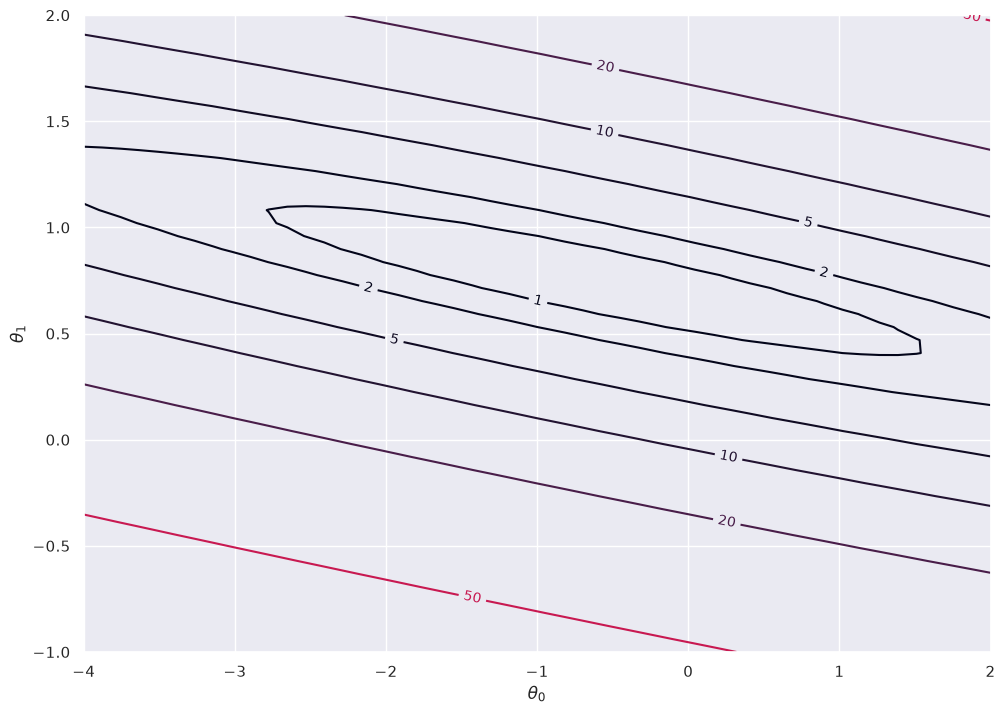

In [27]:
fig, ax = plt.subplots()
XX, YY = np.meshgrid(theta_0s,theta_1s,indexing="ij")
print(YY)
CS = ax.contour(XX, YY, mesh, levels = [1,2,5,10,20,50,100])
ax.clabel(CS, inline=1, fontsize=10)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')

-0.6100958512526007 0.7504014604873275


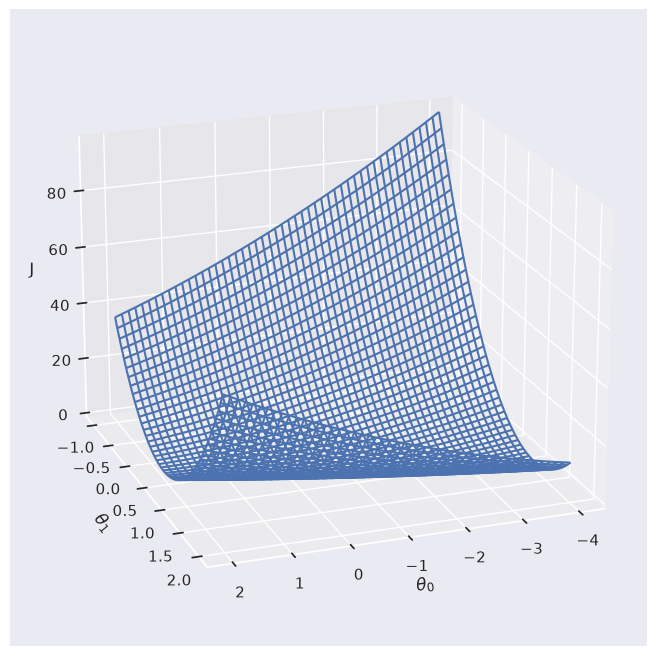

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(20, 70)
ax.plot_wireframe(XX, YY, mesh, rstride=1, cstride=1)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel('J')

theta_0_np, theta_1_np = np.polynomial.Polynomial.fit(x, y, deg=1).convert().coef
print(theta_0_np, theta_1_np)

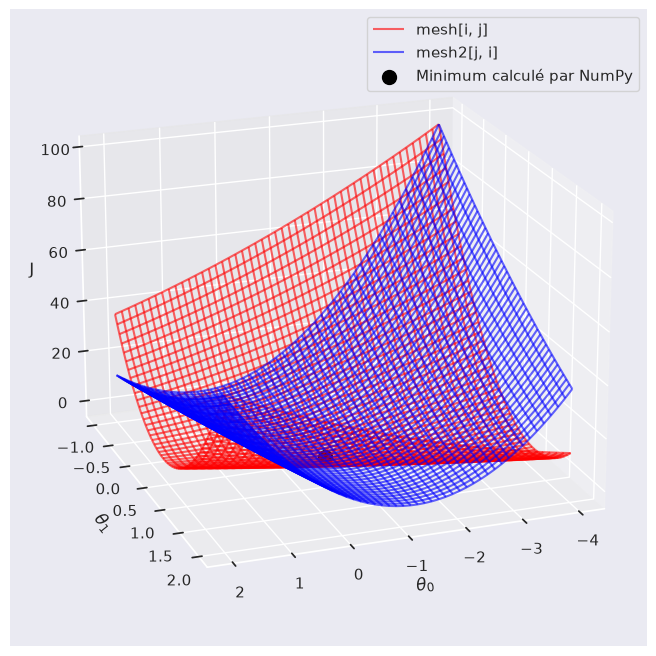

In [29]:
theta_0s = np.linspace(-4,2,50)
theta_1s = np.linspace(-1,2,50)
mesh = np.zeros((50,50))
mesh2 = np.zeros((50,50))

for i, theta0 in enumerate(theta_0s):
    for j, theta1 in enumerate(theta_1s):
        mesh[i,j] = cost_function(x, y, theta0, theta1)
        mesh2[j,i] = cost_function(x, y, theta0, theta1)




theta_0_np, theta_1_np = (
    np.polynomial.Polynomial.fit(x, y, deg=1)
    .convert()
    .coef
)

# Coût obtenu avec les coefficients calculés par NumPy
cost_np = cost_function(x, y, theta_0_np, theta_1_np)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.view_init(20, 70)


    
ax.plot_wireframe(
    XX,
    YY,
    mesh,
    rstride=1,
    cstride=1,
    color="red",
    alpha=0.6,
    label="mesh[i, j]",
    
)

ax.plot_wireframe(
    XX,
    YY,
    mesh2,
    rstride=1,
    cstride=1,
    color="blue",
    alpha=0.6,
    label="mesh2[j, i]"
)

# Point optimal calculé par NumPy
ax.scatter(
    theta_0_np,
    theta_1_np,
    cost_np,
    color="black",
    marker="o",
    s=100,
    label="Minimum calculé par NumPy"
)

ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel("J")

ax.legend()

plt.show()

### 6 - Jeu de données advertising 

In [30]:
import pandas as pd

**Exercice 6**: à l'aide de la bibiothèques *pandas*, lire le fichier `advertising-univariate.csv`

In [31]:
# Compléter le code ci-dessous ~ 1 ligne
df = pd.read_csv("../../data/advertising-multivariate.csv")

#### 6-1 - Préparation de la structure de données

In [32]:
x = df['TV'].values
y = df['sales'].values
x = x/100 # Cette mise à l'échelle permet un meilleur affichage des résultats

#### 6-2 - Affichage des données

Text(0, 0.5, "Ventes (en millier d'unités)")

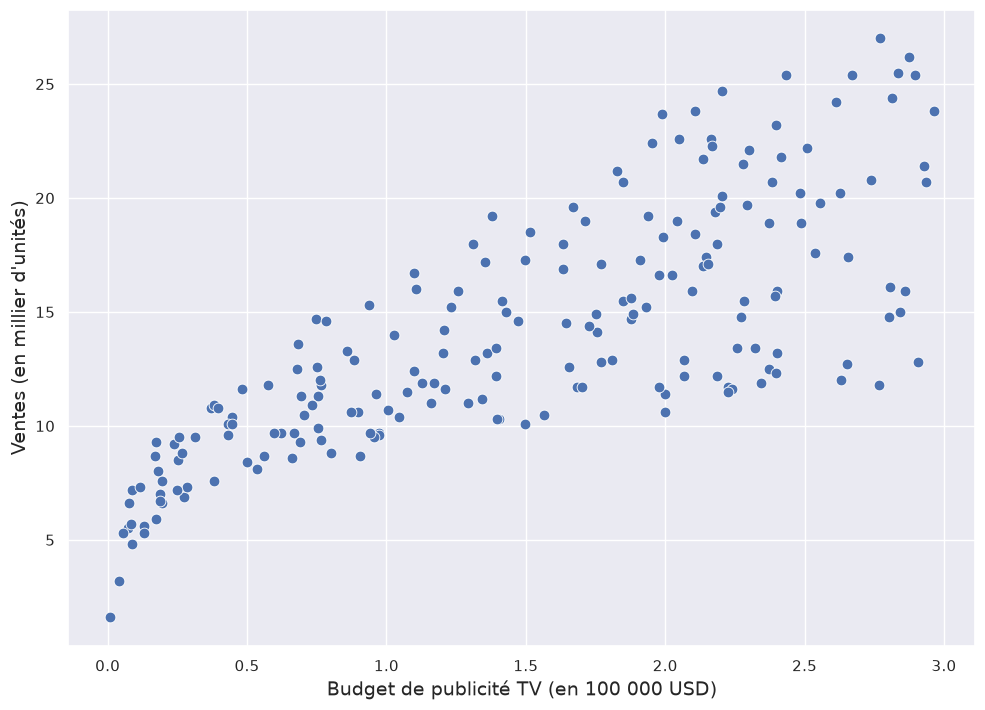

In [33]:
ax = sns.scatterplot(x=x, y=y, s=60)
ax.set_xlabel("Budget de publicité TV (en 100 000 USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)

**Exercice 7**: Faites varier les paramètres $\theta_{0}$ et $\theta_{1}$ de manière à obtenir un bon "fit" sur le jeu de données

Text(0, 25, 'J=5.3329049375')

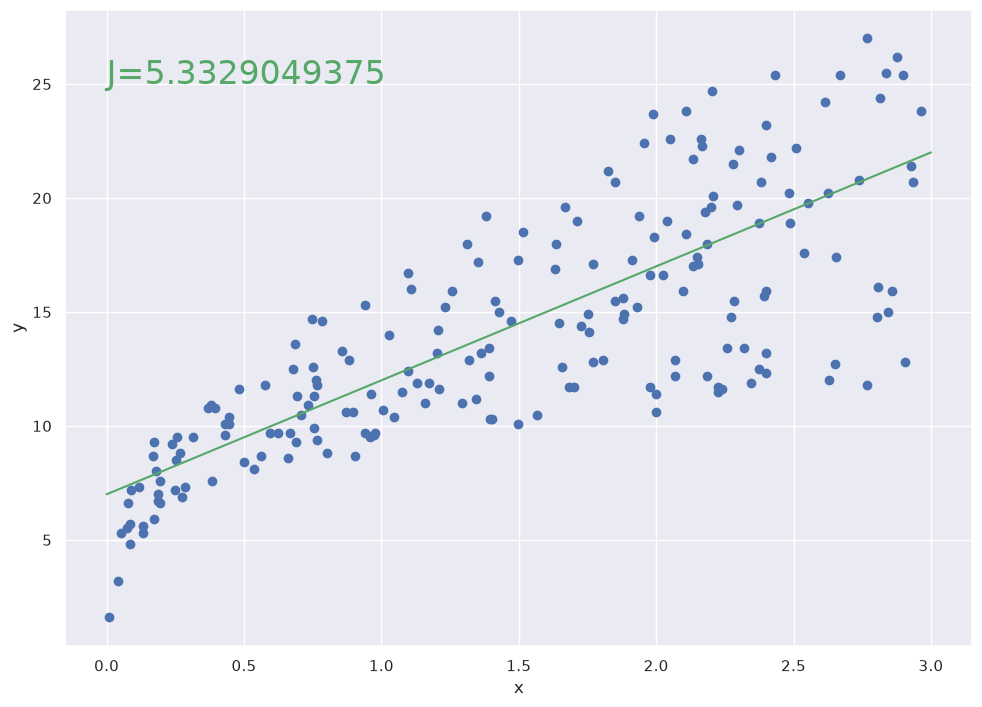

In [64]:
theta_0 = 7
theta_1 = 5

reg_x = np.linspace(0,3,10)
reg_y = hypothesis(np.linspace(0,3,10), theta_0, theta_1)
fig, ax = plt.subplots()
ax.scatter(x,y)
ax.plot(reg_x, reg_y, color="g")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Calcul de la perte
J = cost_function(x,y, theta_0, theta_1)

ax.text(0,25,f'J={J}', color='g', fontsize=24)

#### 6-3 Modèle simplifié

**Exercice 8**: En utlisant le modèle simplifié ($\theta_0$ = 0), quelle est approximativement la valeur de $\theta_1$ qui minimise la fonction de coût ? Pourquoi la valeur semble différente de celle trouvée précédemment ?

Note: le modèle (ou l'hypothèse) sera donc $h_{\theta}(x) = \theta_{1}x$

In [46]:
thetas = np.linspace(7,12,20)
J = []
theta_0 = 0
for theta_1 in thetas:
    J.append(cost_function(x, y, theta_0, theta_1))

Text(0, 0.5, '$J(\\theta_1)$')

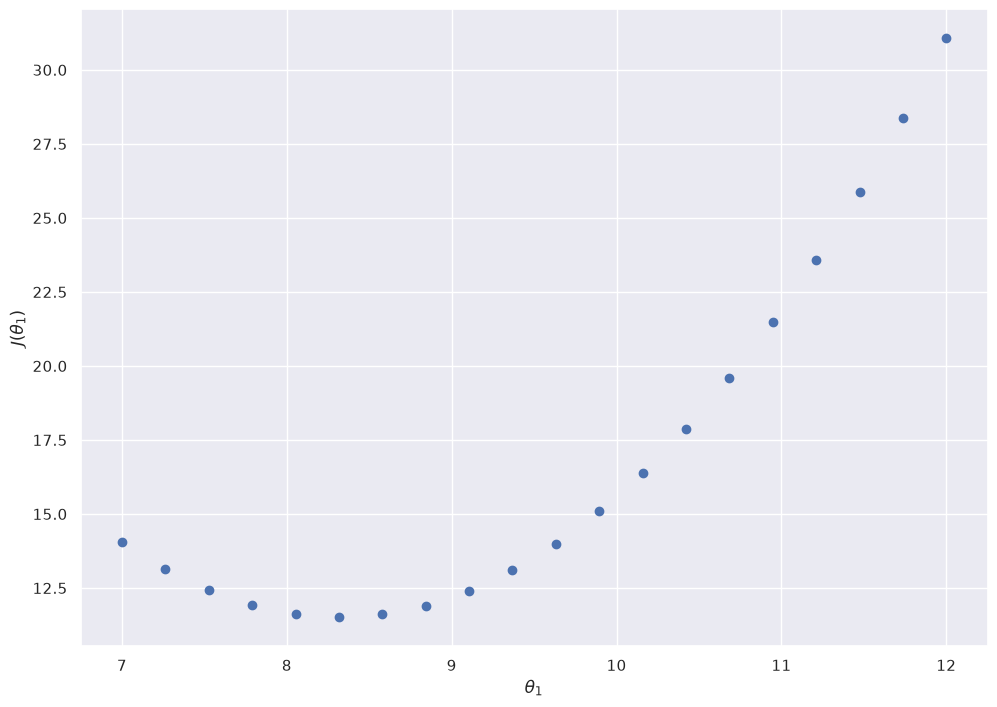

In [47]:
fig, ax = plt.subplots()
ax.scatter(thetas, J)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$J(\theta_1)$")

#### 6-3 Modèle complet

$h_{\theta}(x) = \theta_{0} + \theta_{1}x$

**Exercice 9**: selon la courbe ci-dessus, quelle sont approximativement les valeurs de $\theta_{0}$ et $\theta_{1}$ qui minimisent la fonction de coût ?

In [48]:
theta_0s = np.linspace(4,9,50)
theta_1s = np.linspace(4.5,5.5,50)
mesh = np.zeros((50,50))
for i, theta_0 in enumerate(theta_0s):
    for j, theta_1 in enumerate(theta_1s):
        mesh[j,i] = cost_function(x, y, theta_0, theta_1)

Valeur minimale : 5.256478527638223
theta_0 : 7.061224489795919
theta_1 4.744897959183674
Cout: 5.256478527638223


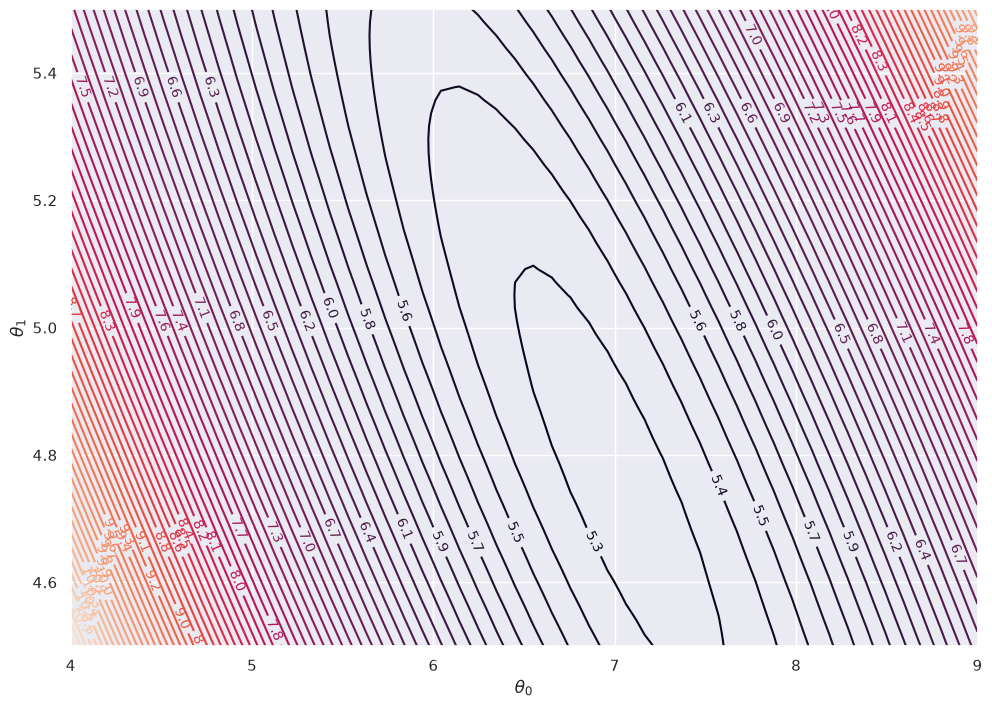

In [61]:
fig, ax = plt.subplots()
XX, YY = np.meshgrid(theta_0s,theta_1s)
CS = ax.contour(XX, YY, mesh, levels=60)
ax.clabel(CS, inline=1, fontsize=10)
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")

indice_min = np.unravel_index(np.argmin(mesh), mesh.shape)

ligne, colonne = indice_min



print("Valeur minimale :", mesh[ligne, colonne])
print("theta_0 :",  theta_0s[colonne])
print("theta_1",  theta_1s[ligne])

print('Cout:', cost_function(x,y,theta_0s[colonne], theta_1s[ligne]))

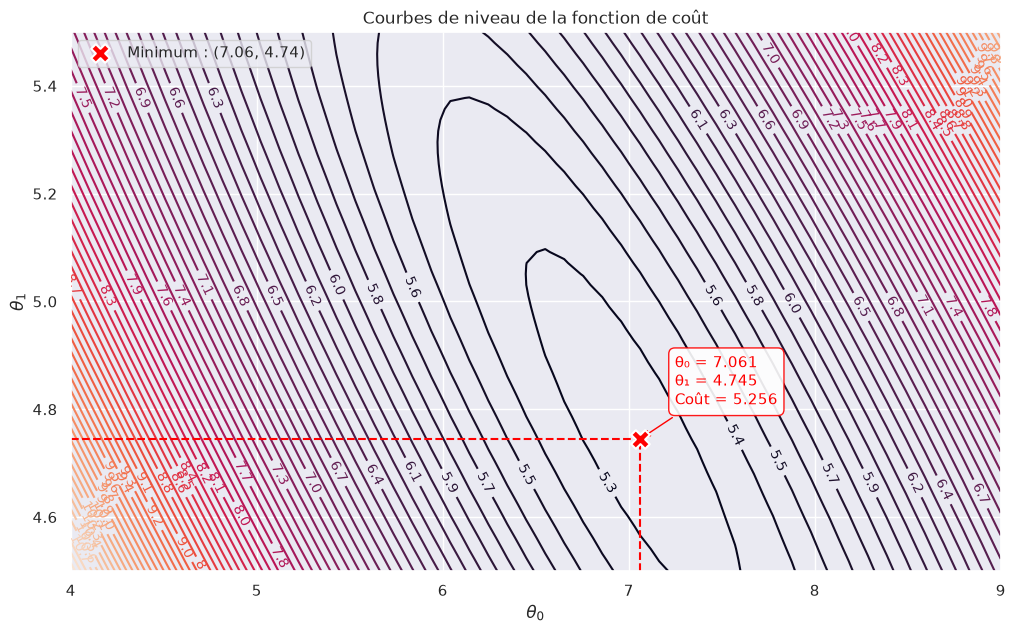

Indices (ligne, colonne) : 12 30
Valeur minimale : 5.256478527638223
theta_0 : 7.061224489795919
theta_1 : 4.744897959183674


In [65]:
# Bloc 2

fig, ax = plt.subplots(figsize=(12, 7))

XX, YY = np.meshgrid(theta_0s, theta_1s)

CS = ax.contour(
    XX,
    YY,
    mesh,
    levels=60
)

ax.clabel(
    CS,
    inline=True,
    fontsize=10
)

# Trouver les indices du coût minimal
ligne, colonne = np.unravel_index(
    np.argmin(mesh),
    mesh.shape
)

# Retrouver les valeurs de theta correspondantes
theta_0_min = theta_0s[colonne]
theta_1_min = theta_1s[ligne]
cout_min = mesh[ligne, colonne]

# Afficher le minimum
ax.scatter(
    theta_0_min,
    theta_1_min,
    color="red",
    marker="X",
    s=180,
    edgecolor="white",
    linewidth=1.5,
    zorder=5,
    label=f"Minimum : ({theta_0_min:.2f}, {theta_1_min:.2f})"
)

# Projection du minimum vers l'axe theta_0
ax.vlines(
    x=theta_0_min,
    ymin=theta_1s.min(),
    ymax=theta_1_min,
    colors="red",
    linestyles="--",
    linewidth=1.5
)

# Projection du minimum vers l'axe theta_1
ax.hlines(
    y=theta_1_min,
    xmin=theta_0s.min(),
    xmax=theta_0_min,
    colors="red",
    linestyles="--",
    linewidth=1.5
)

# Afficher les valeurs près du minimum
ax.annotate(
    f"θ₀ = {theta_0_min:.3f}\n"
    f"θ₁ = {theta_1_min:.3f}\n"
    f"Coût = {cout_min:.3f}",
    xy=(theta_0_min, theta_1_min),
    xytext=(25, 25),
    textcoords="offset points",
    fontsize=11,
    color="red",
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "red",
        "alpha": 0.9
    },
    arrowprops={
        "arrowstyle": "->",
        "color": "red"
    }
)

ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_title("Courbes de niveau de la fonction de coût")

ax.legend()
plt.show()

print("Indices (ligne, colonne) :", ligne, colonne)
print("Valeur minimale :", cout_min)
print("theta_0 :", theta_0_min)
print("theta_1 :", theta_1_min)

### Fin de l'atelier